In [4]:
# Standard Library
import os
import math
import random
import shutil

# Data Processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Computer Vision
import cv2

# PyTorch Core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Torchvision
from torchvision import datasets, transforms, models

# Utility
from glob import glob

import sys
sys.path.insert(0, '/content/drive/MyDrive/Covid/Scripts')

print(torch.__version__)

2.10.0+cu128


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
data_path = '/content/drive/MyDrive/Covid/'
path_positive_images = "/content/drive/MyDrive/Covid/CT_COVID"
path_negative_images = "/content/drive/MyDrive/Covid/CT_NonCOVID"

In [9]:
positive_images_paths = glob(os.path.join(path_positive_images, "*.[pj][np][gg]*"))
negative_images_paths = glob(os.path.join(path_negative_images, "*.[pj][np][gg]*"))

print(f"Found {len(positive_images_paths)} positive images.")
print(f"Found {len(negative_images_paths)} negative images.")

Found 349 positive images.
Found 397 negative images.


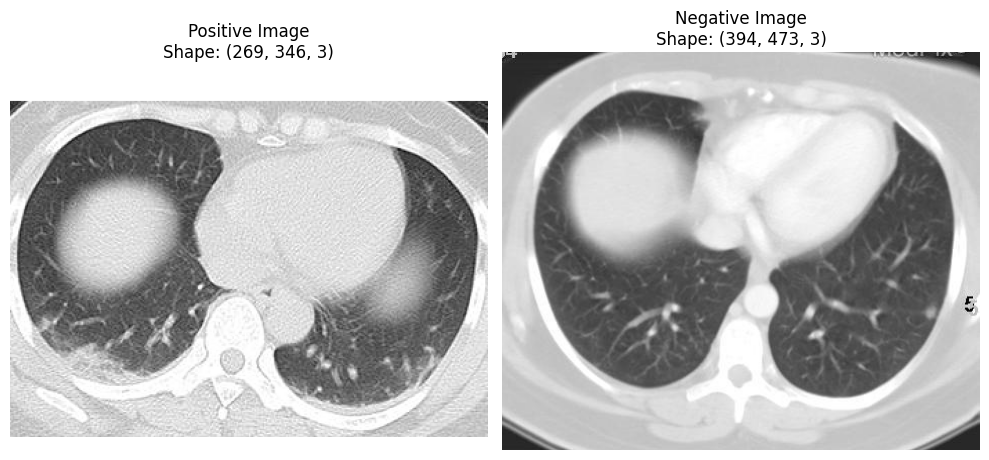

In [10]:
def show_random_images(positive_paths, negative_paths):
    pos_img = cv2.imread(random.choice(positive_paths))
    neg_img = cv2.imread(random.choice(negative_paths))

    pos_img = cv2.cvtColor(pos_img, cv2.COLOR_BGR2RGB)
    neg_img = cv2.cvtColor(neg_img, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(pos_img)
    axes[0].set_title(f"Positive Image\nShape: {pos_img.shape}")
    axes[0].axis("off")

    axes[1].imshow(neg_img)
    axes[1].set_title(f"Negative Image\nShape: {neg_img.shape}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(positive_images_paths, negative_images_paths)

# Dataset Modification

In [11]:
from data_prep import create_dataset_structure

create_dataset_structure(data_path, positive_images_paths, negative_images_paths)

Dataset structure created successfully!

Covid/
├── train/
│   ├── positive/  (279 images)
│   └── negative/  (317 images)
└── test/
    ├── positive/  (70 images)
    └── negative/  (80 images)


In [12]:
train_dir = "/content/drive/MyDrive/Covid/train"
test_dir  = "/content/drive/MyDrive/Covid/test"

In [13]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(root=train_dir,
                                  transform=train_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=train_transform)

print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 596
    Root location: /content/drive/MyDrive/Covid/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 150
    Root location: /content/drive/MyDrive/Covid/test
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.2

In [14]:
class_names = train_data.classes
class_names

['negative', 'positive']

In [15]:
class_dict = train_data.class_to_idx
class_dict

{'negative': 0, 'positive': 1}

In [16]:
from torch.utils.data import DataLoader
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=8,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=8,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bdfd6607830>,
 <torch.utils.data.dataloader.DataLoader at 0x7bdfd65bdac0>)

In [17]:
img, label = next(iter(train_dataloader))
print(f"Image shape: {img.shape} -> [batch_size, color_channels, height, width]")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([8, 3, 64, 64]) -> [batch_size, color_channels, height, width]
Label shape: torch.Size([8])


In [19]:
from Model_creation import CovidCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = CovidCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f"\nUsing device: {device}")

CovidCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=

In [21]:
from engine import train , train_step , test_step

torch.manual_seed(42)
torch.cuda.manual_seed(42)

results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=criterion,
                epochs=10,
                device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 12.0907 | train_acc: 0.4850 | test_loss: 7.6291 | test_acc: 0.5526
Epoch: 2 | train_loss: 7.9277 | train_acc: 0.5250 | test_loss: 7.7365 | test_acc: 0.5965
Epoch: 3 | train_loss: 7.6526 | train_acc: 0.5650 | test_loss: 7.6497 | test_acc: 0.6360
Epoch: 4 | train_loss: 7.4351 | train_acc: 0.6083 | test_loss: 7.7265 | test_acc: 0.6316
Epoch: 5 | train_loss: 7.3682 | train_acc: 0.6450 | test_loss: 7.6212 | test_acc: 0.6930
Epoch: 6 | train_loss: 7.4498 | train_acc: 0.6650 | test_loss: 7.7369 | test_acc: 0.6689
Epoch: 7 | train_loss: 7.2804 | train_acc: 0.6800 | test_loss: 7.6348 | test_acc: 0.7412
Epoch: 8 | train_loss: 7.3484 | train_acc: 0.6583 | test_loss: 7.7423 | test_acc: 0.6952
Epoch: 9 | train_loss: 7.2291 | train_acc: 0.7017 | test_loss: 7.7329 | test_acc: 0.7215
Epoch: 10 | train_loss: 7.2140 | train_acc: 0.6617 | test_loss: 7.6718 | test_acc: 0.6886


In [22]:
from pathlib import Path

def save_model(model: torch.nn.Module,
               target_dir: str,
               model_name: str):
  target_dir_path = Path(target_dir)
  target_dir_path.mkdir(parents=True,
                        exist_ok=True)

  assert model_name.endswith(".pth") or model_name.endswith(".pt"), "model_name should end with '.pt' or '.pth'"
  model_save_path = target_dir_path / model_name

  print(f"[INFO] Saving model to: {model_save_path}")
  torch.save(obj=model.state_dict(),
             f=model_save_path)

In [23]:
save_model(model=model,
           target_dir="/content/drive/MyDrive/Covid/models",
           model_name="covid_cnn.pth")

[INFO] Saving model to: /content/drive/MyDrive/Covid/models/covid_cnn.pth


In [24]:
from timeit import default_timer as timer

torch.manual_seed(42)
torch.cuda.manual_seed(42)

NUM_EPOCHS = 10

model = CovidCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

start_time = timer()

results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=criterion,
                epochs=NUM_EPOCHS,
                device=device)

end_time = timer()
print(f"[INFO] Total training time: {end_time - start_time:.3f} seconds")

save_model(model=model,
           target_dir="/content/drive/MyDrive/Covid/models",
           model_name="covid_cnn.pth")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9135 | train_acc: 0.5433 | test_loss: 0.6847 | test_acc: 0.5263
Epoch: 2 | train_loss: 0.6514 | train_acc: 0.6383 | test_loss: 0.6299 | test_acc: 0.6316
Epoch: 3 | train_loss: 0.6123 | train_acc: 0.6600 | test_loss: 0.7001 | test_acc: 0.6447
Epoch: 4 | train_loss: 0.5844 | train_acc: 0.6967 | test_loss: 0.5284 | test_acc: 0.6908
Epoch: 5 | train_loss: 0.5609 | train_acc: 0.7100 | test_loss: 0.5564 | test_acc: 0.6886
Epoch: 6 | train_loss: 0.5737 | train_acc: 0.7100 | test_loss: 0.5480 | test_acc: 0.7281
Epoch: 7 | train_loss: 0.5675 | train_acc: 0.7117 | test_loss: 0.5100 | test_acc: 0.7127
Epoch: 8 | train_loss: 0.5601 | train_acc: 0.7067 | test_loss: 0.5108 | test_acc: 0.7193
Epoch: 9 | train_loss: 0.5326 | train_acc: 0.7350 | test_loss: 0.4981 | test_acc: 0.7675
Epoch: 10 | train_loss: 0.5108 | train_acc: 0.7433 | test_loss: 0.5257 | test_acc: 0.7939
[INFO] Total training time: 68.725 seconds
[INFO] Saving model to: /content/drive/MyDrive/Covid/models/covid_